[Reference](https://medium.com/@Rohan_Dutt/10-data-visualization-techniques-every-data-analyst-should-master-based-on-core-visualization-11b4980a8e4c$0)

# 1. Use the “Right-to-Left” Principle for Hierarchy


/tmp/ipykernel_2410/4156907328.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range('2023-01-01', periods=12, freq='M')


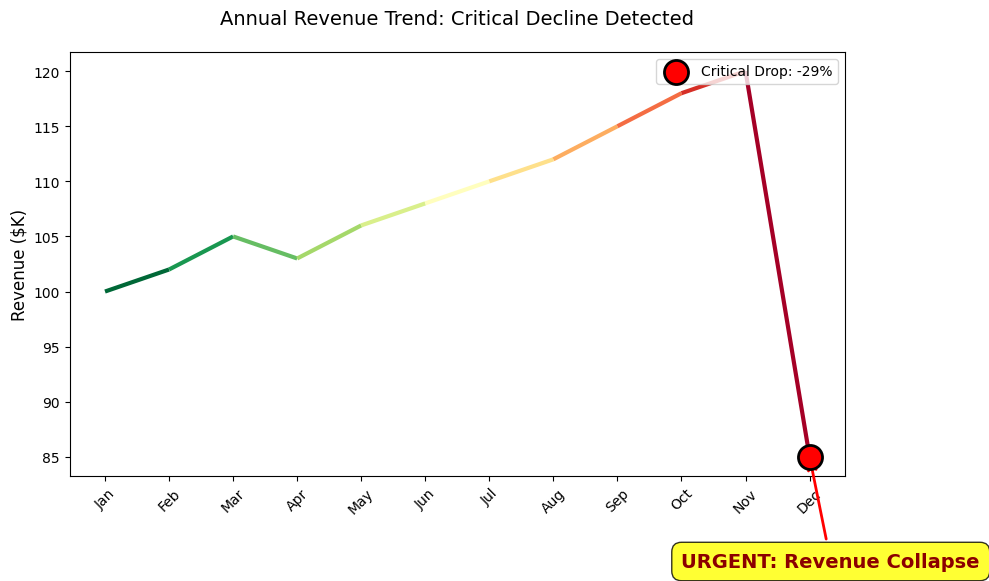

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Generate data with critical drop at the end
dates = pd.date_range('2023-01-01', periods=12, freq='M')
revenue = [100, 102, 105, 103, 106, 108, 110, 112, 115, 118, 120, 85]  # Crash at end
fig, ax = plt.subplots(figsize=(10, 6))
# Plot line with gradient color emphasizing the right side
points = np.array([range(len(dates)), revenue]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
from matplotlib.collections import LineCollection
lc = LineCollection(segments, cmap='RdYlGn_r', linewidth=3)
lc.set_array(np.linspace(0, 1, len(segments)))
ax.add_collection(lc)
# Highlight the critical rightmost point
ax.scatter(len(dates)-1, revenue[-1], color='red', s=300, zorder=5,
           edgecolors='black', linewidth=2, label='Critical Drop: -29%')
# Add annotation on the right side
ax.annotate('URGENT: Revenue Collapse',
             xy=(len(dates)-1, revenue[-1]),
             xytext=(len(dates)-3, revenue[-1]-10),
             fontsize=14, fontweight='bold', color='darkred',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.8),
             arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.set_xticks(range(len(dates)))
ax.set_xticklabels([d.strftime('%b') for d in dates], rotation=45)
ax.set_ylabel('Revenue ($K)', fontsize=12)
ax.set_title('Annual Revenue Trend: Critical Decline Detected', fontsize=14, pad=20)
ax.legend()
plt.tight_layout()
plt.show()

# 2. Steal from Cartography: The “Layered Detail” Trick


/tmp/ipykernel_2410/313135119.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  'Month': pd.date_range('2023-01', periods=6, freq='M'),


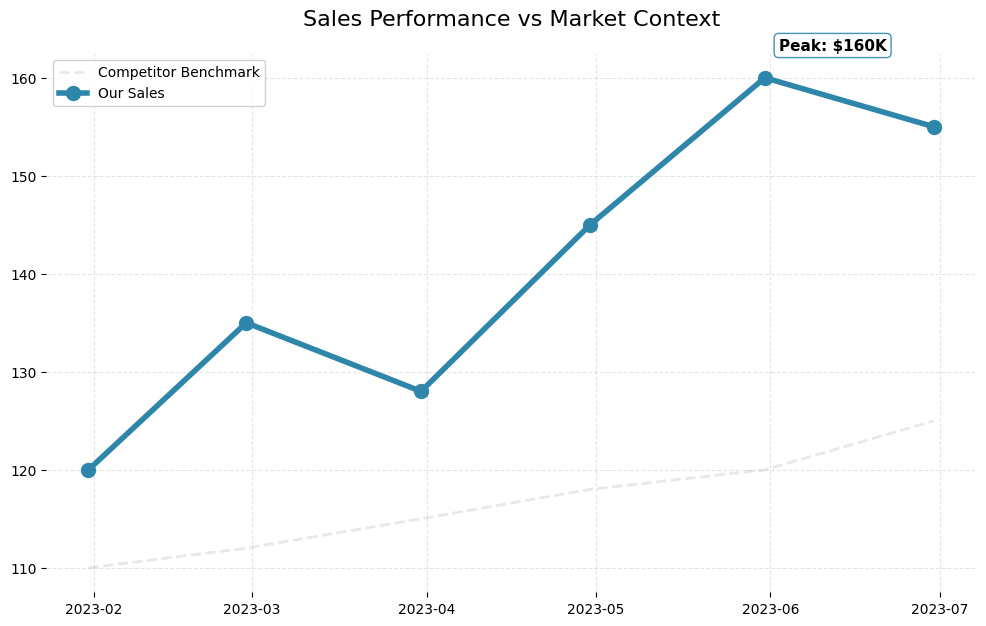

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create complex dataset with multiple layers
np.random.seed(42)
df = pd.DataFrame({
    'Month': pd.date_range('2023-01', periods=6, freq='M'),
    'Primary_Sales': [120, 135, 128, 145, 160, 155],
    'Competitor_Avg': [110, 112, 115, 118, 120, 125],
    'Market_Cap': [1000, 1050, 1020, 1100, 1150, 1120]
})
fig, ax = plt.subplots(figsize=(12, 7))
# Layer 1: Faint background grid (30% opacity)
ax.grid(True, alpha=0.2, linestyle='--', color='gray', zorder=0)
# Layer 2: Context data (faint competitor benchmark)
ax.plot(df['Month'], df['Competitor_Avg'], color='lightgray', linewidth=2,
        alpha=0.5, linestyle='--', label='Competitor Benchmark', zorder=1)
# Layer 3: Primary data (bold)
ax.plot(df['Month'], df['Primary_Sales'], color='#2E86AB', linewidth=4,
        marker='o', markersize=10, label='Our Sales', zorder=3)
# Layer 4: Annotations (top layer)
for i, (date, val) in enumerate(zip(df['Month'], df['Primary_Sales'])):
    if val == df['Primary_Sales'].max():
        ax.annotate(f'Peak: ${val}K', xy=(date, val), xytext=(10, 20),
                   textcoords='offset points', fontsize=11, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                             edgecolor='#2E86AB', alpha=0.9), zorder=4)
ax.set_title('Sales Performance vs Market Context', fontsize=16, pad=20)
ax.legend(loc='upper left', framealpha=0.9)
sns.despine(left=True, bottom=True)
plt.show()

# 3. The 3-Second Rule: Design for Instant “Aha!”

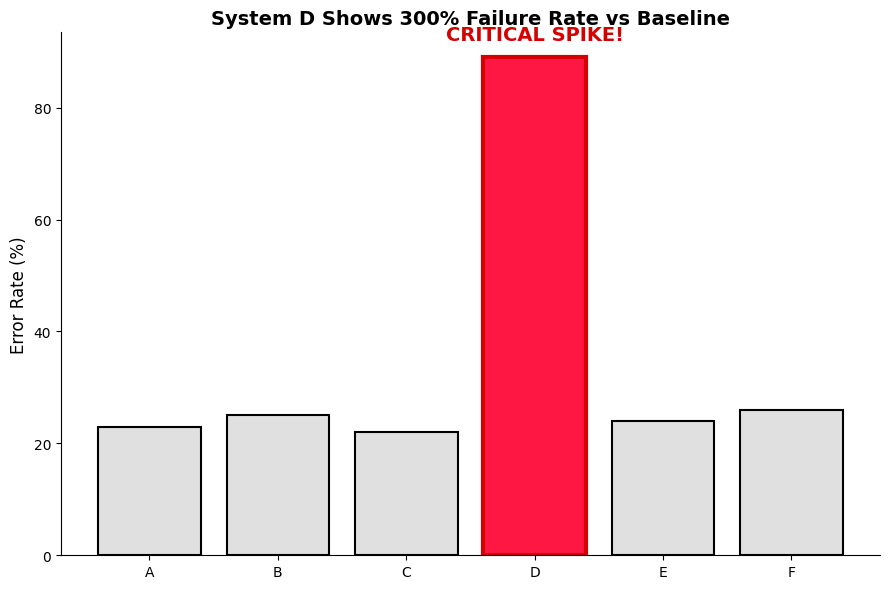

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Create data where one element is obviously different
categories = ['A', 'B', 'C', 'D', 'E', 'F']
values = [23, 25, 22, 89, 24, 26]  # D is the outlier
fig, ax = plt.subplots(figsize=(9, 6))
# Pre-attentive processing: Use color and size to highlight the "aha" moment
colors = ['#E0E0E0' if v < 50 else '#FF1744' for v in values]
sizes = [400 if v < 50 else 1200 for v in values]
bars = ax.bar(categories, values, color=colors, edgecolor='black', linewidth=1.5)
# Add size emphasis to the critical bar
for i, (bar, val) in enumerate(zip(bars, values)):
    if val > 50:
        bar.set_linewidth(3)
        bar.set_edgecolor('#D50000')
        # Instant annotation
        ax.text(i, val + 3, 'CRITICAL SPIKE!', ha='center', fontweight='bold',
                fontsize=14, color='#D50000')
# Remove clutter that slows recognition
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Error Rate (%)', fontsize=12)
ax.set_title('System D Shows 300% Failure Rate vs Baseline', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Abandon Pie Charts (Except for This One Case)


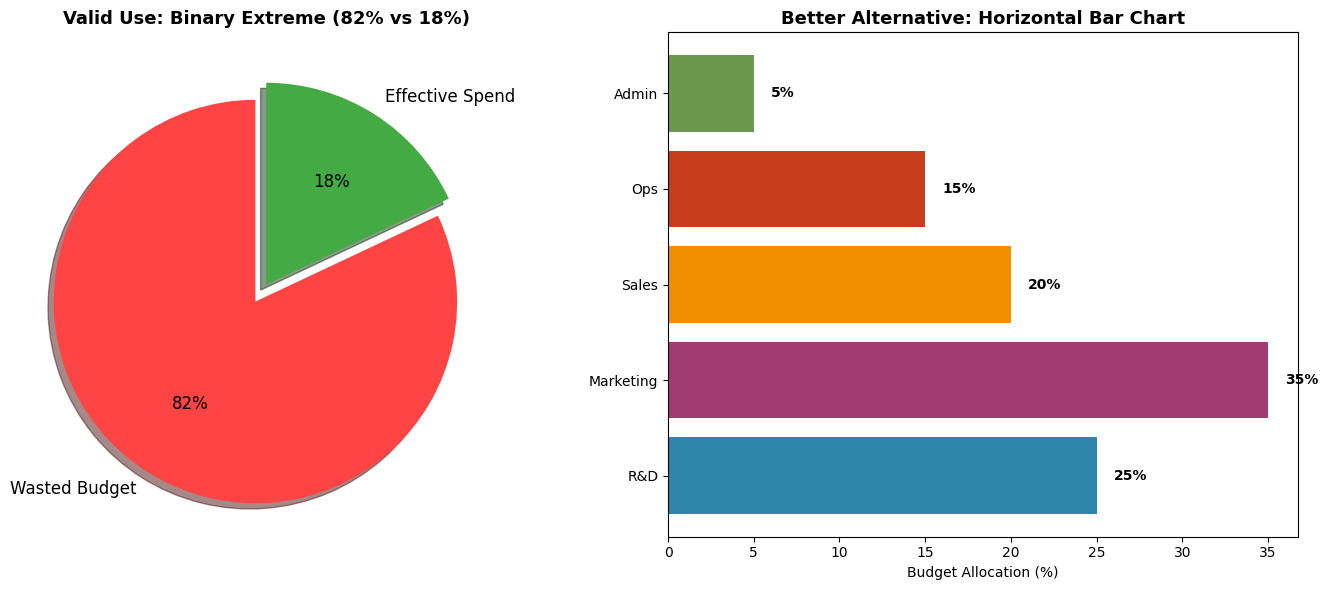

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Scenario: Valid pie use case (extreme contrast)
labels_valid = ['Wasted Budget', 'Effective Spend']
sizes_valid = [82, 18]
colors_valid = ['#FF4444', '#44AA44']
# Scenario: Better as bar chart (multiple categories)
categories = ['R&D', 'Marketing', 'Sales', 'Ops', 'Admin']
values = [25, 35, 20, 15, 5]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
# Valid Pie: Extreme binary contrast
wedges, texts, autotexts = ax1.pie(sizes_valid, labels=labels_valid,
                                     colors=colors_valid, autopct='%1.0f%%',
                                     startangle=90, explode=(0.1, 0),
                                     shadow=True, textprops={'fontsize': 12})
ax1.set_title('Valid Use: Binary Extreme (82% vs 18%)', fontsize=13, fontweight='bold')
# Alternative: Horizontal bar for multiple categories
y_pos = np.arange(len(categories))
bars = ax2.barh(y_pos, values, color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E'])
ax2.set_yticks(y_pos)
ax2.set_yticklabels(categories)
ax2.set_xlabel('Budget Allocation (%)')
ax2.set_title('Better Alternative: Horizontal Bar Chart', fontsize=13, fontweight='bold')
# Add value labels
for i, (bar, val) in enumerate(zip(bars, values)):
    ax2.text(val + 1, i, f'{val}%', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

# 5. “False Dimensions” for Strategic Distortion


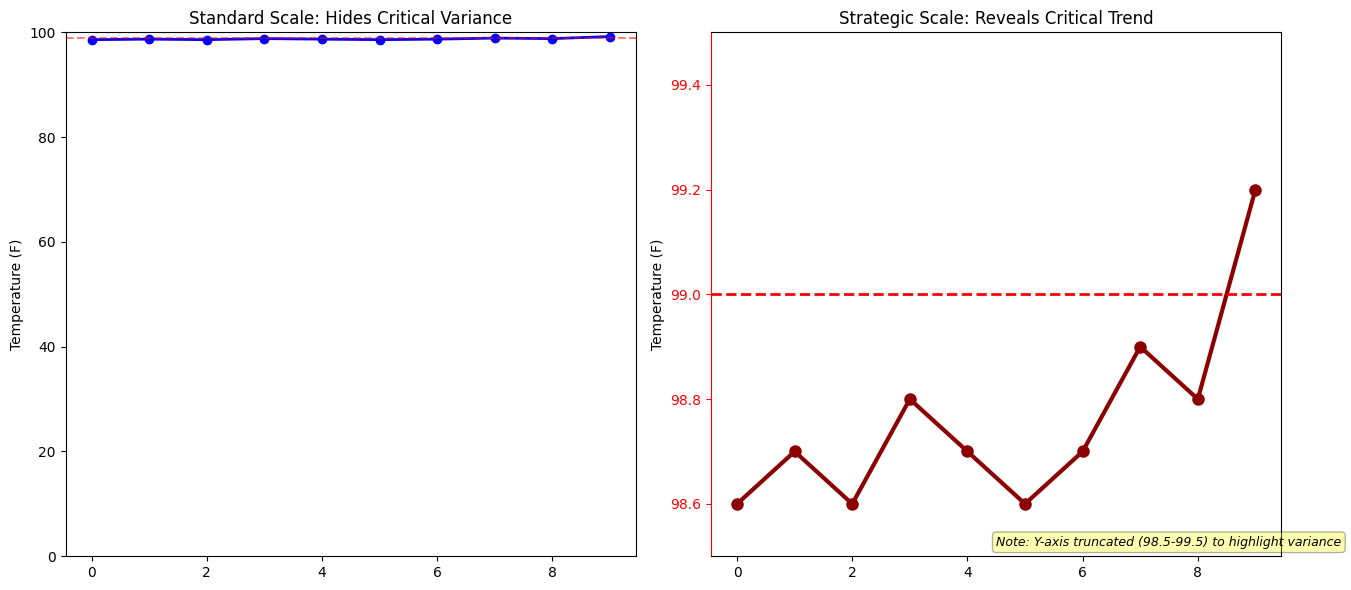

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Data: Small but critical variance in temperature stability
time_points = np.arange(10)
temp_stable = [98.6, 98.7, 98.6, 98.8, 98.7, 98.6, 98.7, 98.9, 98.8, 99.2]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
# Left: Truthful but flat (full scale)
ax1.plot(time_points, temp_stable, marker='o', linewidth=2, color='blue')
ax1.set_ylim(0, 100)
ax1.set_title('Standard Scale: Hides Critical Variance', fontsize=12)
ax1.set_ylabel('Temperature (F)')
ax1.axhline(y=99.0, color='red', linestyle='--', alpha=0.5, label='Fever Threshold')
# Right: Strategic distortion (truncated axis with transparency disclaimer)
ax2.plot(time_points, temp_stable, marker='o', linewidth=3, color='darkred', markersize=8)
ax2.set_ylim(98.5, 99.5)  # Truncated to show variance
ax2.set_title('Strategic Scale: Reveals Critical Trend', fontsize=12)
ax2.set_ylabel('Temperature (F)')
ax2.axhline(y=99.0, color='red', linestyle='--', linewidth=2, label='Fever Threshold')
# Add break lines and disclaimer
ax2.spines['left'].set_color('red')
ax2.tick_params(axis='y', colors='red')
# Transparent annotation
ax2.text(0.5, 0.02, 'Note: Y-axis truncated (98.5-99.5) to highlight variance',
         transform=ax2.transAxes, fontsize=9, style='italic',
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
plt.tight_layout()
plt.show()

# 6. The “North Star” Anchor

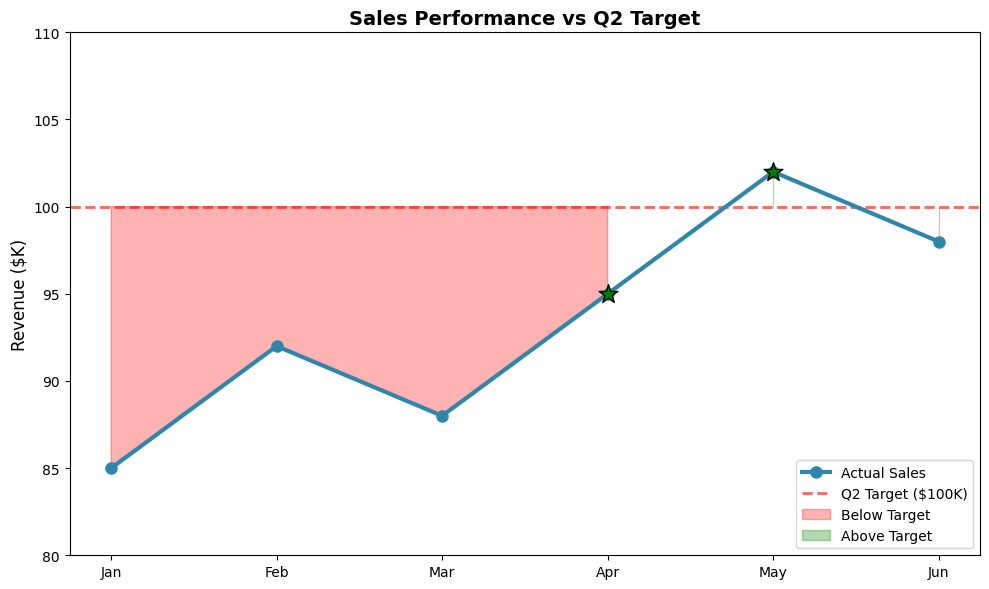

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Sales data with target benchmark
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
actual_sales = [85, 92, 88, 95, 102, 98]
target = 100  # The North Star
fig, ax = plt.subplots(figsize=(10, 6))
# Plot actual performance
ax.plot(months, actual_sales, marker='o', linewidth=3, markersize=8,
        color='#2E86AB', label='Actual Sales', zorder=3)
# The North Star: Static reference line
ax.axhline(y=target, color='#F24236', linestyle='--', linewidth=2,
           alpha=0.8, label='Q2 Target ($100K)', zorder=1)
# Fill areas above/below target for instant context
ax.fill_between(months, actual_sales, target,
                where=[a < target for a in actual_sales],
                alpha=0.3, color='red', label='Below Target')
ax.fill_between(months, actual_sales, target,
                where=[a >= target for a in actual_sales],
                alpha=0.3, color='green', label='Above Target')
# Highlight achievement
ax.scatter([months[i] for i in [3, 4]],
           [actual_sales[i] for i in [3, 4]],
           color='green', s=200, zorder=4, marker='*', edgecolors='black')
ax.set_ylabel('Revenue ($K)', fontsize=12)
ax.set_title('Sales Performance vs Q2 Target', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.set_ylim(80, 110)
plt.tight_layout()
plt.show()

# 7. Texture Over Color for Accessibility


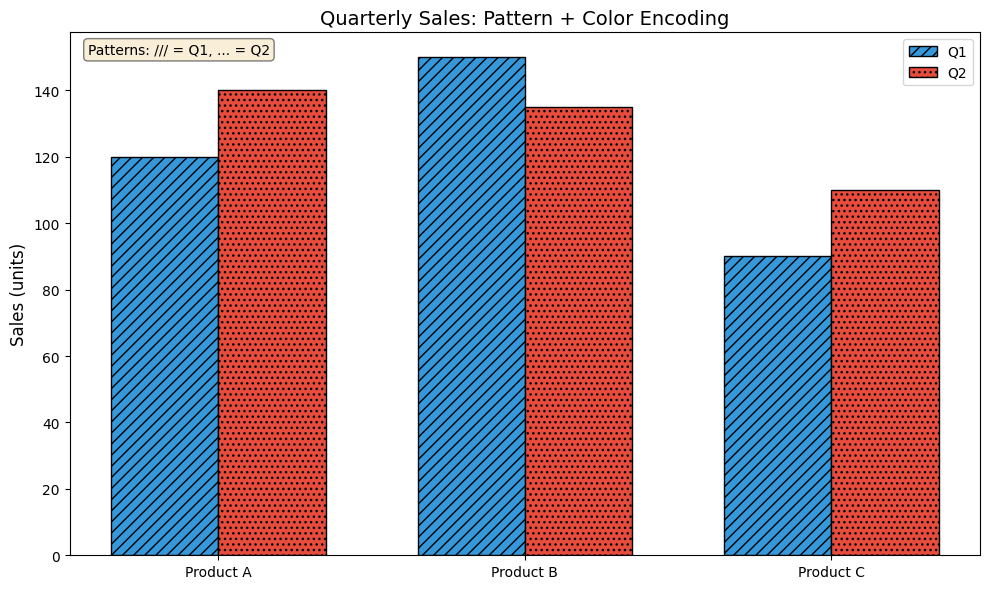

In [7]:
import matplotlib.pyplot as plt
import numpy as np

categories = ['Product A', 'Product B', 'Product C']
q1_sales = [120, 150, 90]
q2_sales = [140, 135, 110]
x = np.arange(len(categories))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
# Using hatching patterns for texture differentiation
bars1 = ax.bar(x - width/2, q1_sales, width, label='Q1',
               color='#3498db', hatch='///', edgecolor='black', linewidth=1)
bars2 = ax.bar(x + width/2, q2_sales, width, label='Q2',
               color='#e74c3c', hatch='...', edgecolor='black', linewidth=1)
# Add texture legend explanation
ax.text(0.02, 0.98, 'Patterns: /// = Q1, ... = Q2',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.set_ylabel('Sales (units)', fontsize=12)
ax.set_title('Quarterly Sales: Pattern + Color Encoding', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
# Verify with grayscale simulation
plt.setp(ax, facecolor='white')
plt.tight_layout()
plt.show()

# 8. The “Banner Headline” Chart Title


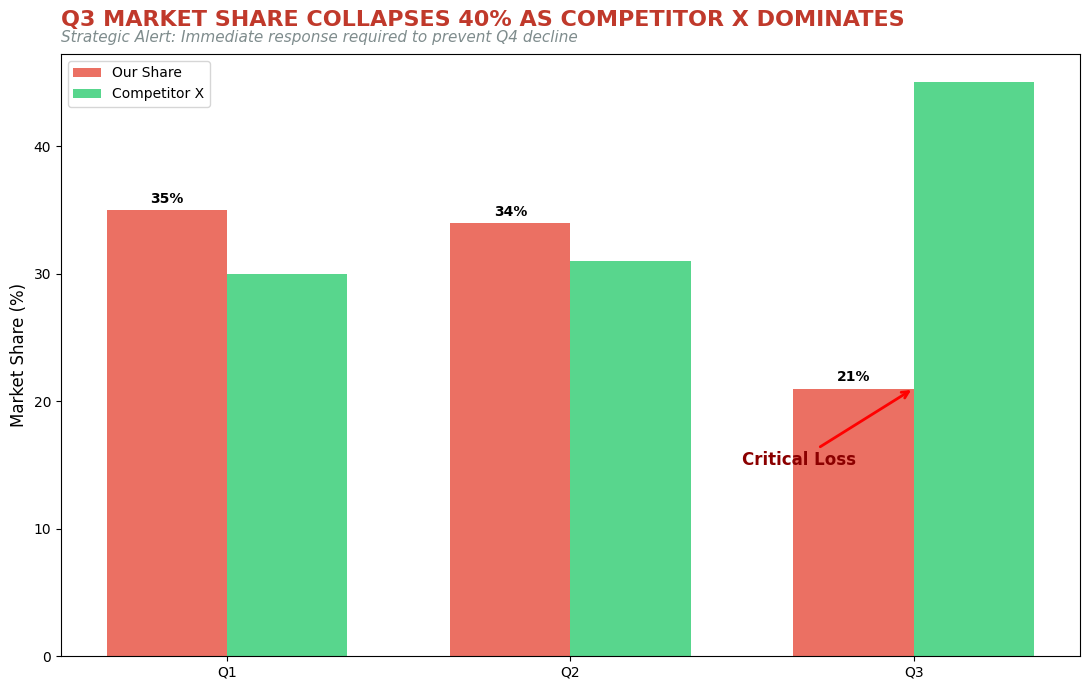

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Data showing the story
quarters = ['Q1', 'Q2', 'Q3']
market_share = [35, 34, 21]  # The drop
competitor = [30, 31, 45]
fig, ax = plt.subplots(figsize=(11, 7))
# Create the visual story
x = np.arange(len(quarters))
width = 0.35
bars1 = ax.bar(x - width/2, market_share, width, label='Our Share',
               color='#e74c3c', alpha=0.8)
bars2 = ax.bar(x + width/2, competitor, width, label='Competitor X',
               color='#2ecc71', alpha=0.8)
# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontweight='bold')
# The Banner Headline technique
ax.set_title('Q3 MARKET SHARE COLLAPSES 40% AS COMPETITOR X DOMINATES',
             fontsize=16, fontweight='bold', pad=20, loc='left',
             color='#c0392b')
# Subtitle with context
ax.text(0.0, 1.02, 'Strategic Alert: Immediate response required to prevent Q4 decline',
        transform=ax.transAxes, fontsize=11, style='italic', color='#7f8c8d')
ax.set_ylabel('Market Share (%)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(quarters)
ax.legend()
# Add dramatic annotation
ax.annotate('Critical Loss', xy=(2, 21), xytext=(1.5, 15),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=12, fontweight='bold', color='darkred')
plt.tight_layout()
plt.show()

# 9. Animate Sparingly, But Smart


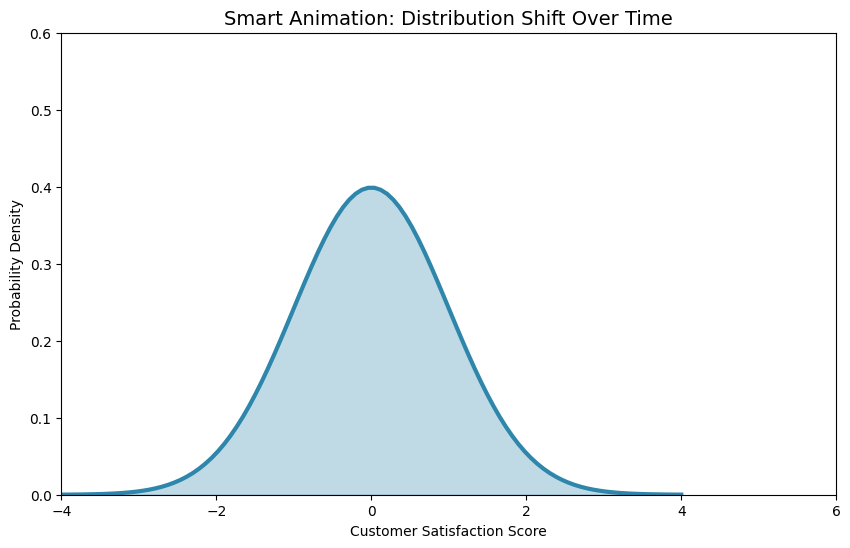

Animation demonstrates how the customer satisfaction distribution shifted from normal to crisis state over 6 months.


In [9]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# Data showing distribution shift over time
np.random.seed(42)
fig, ax = plt.subplots(figsize=(10, 6))
# Initial state: Normal distribution
x = np.linspace(-4, 4, 100)
initial_curve = (1/np.sqrt(2*np.pi)) * np.exp(-0.5*x**2)
# Target state: Shifted and skewed
target_curve = (1/np.sqrt(2*np.pi*0.5)) * np.exp(-0.5*((x-2)/0.8)**2)
line, = ax.plot(x, initial_curve, linewidth=3, color='#2E86AB')
fill = ax.fill_between(x, initial_curve, alpha=0.3, color='#2E86AB')
ax.set_xlim(-4, 6)
ax.set_ylim(0, 0.6)
ax.set_title('Smart Animation: Distribution Shift Over Time', fontsize=14)
ax.set_xlabel('Customer Satisfaction Score')
ax.set_ylabel('Probability Density')
# Animation function: Morphing between states
def animate(frame):
    # Interpolate between initial and target
    alpha = frame / 100
    current = (1-alpha) * initial_curve + alpha * target_curve

    line.set_ydata(current)

    # Clear and refill (required for fill_between animation)
    global fill
    fill.remove()
    fill = ax.fill_between(x, current, alpha=0.3, color='#e74c3c' if alpha > 0.5 else '#2E86AB')

    if frame == 0:
        ax.text(0, 0.55, 'Initial State', fontsize=12, ha='center')
    elif frame == 99:
        ax.text(2, 0.55, 'Current Crisis State', fontsize=12, ha='center', color='red')

    return line, fill
# Create animation
ani = animation.FuncAnimation(fig, animate, frames=100, interval=50, blit=False)
# Save as GIF (requires imagemagick or pillow)
# ani.save('distribution_shift.gif', writer='pillow', fps=20)
plt.show()
print("Animation demonstrates how the customer satisfaction distribution shifted from normal to crisis state over 6 months.")

# 10. The “Blink Test” for Emotional Impact


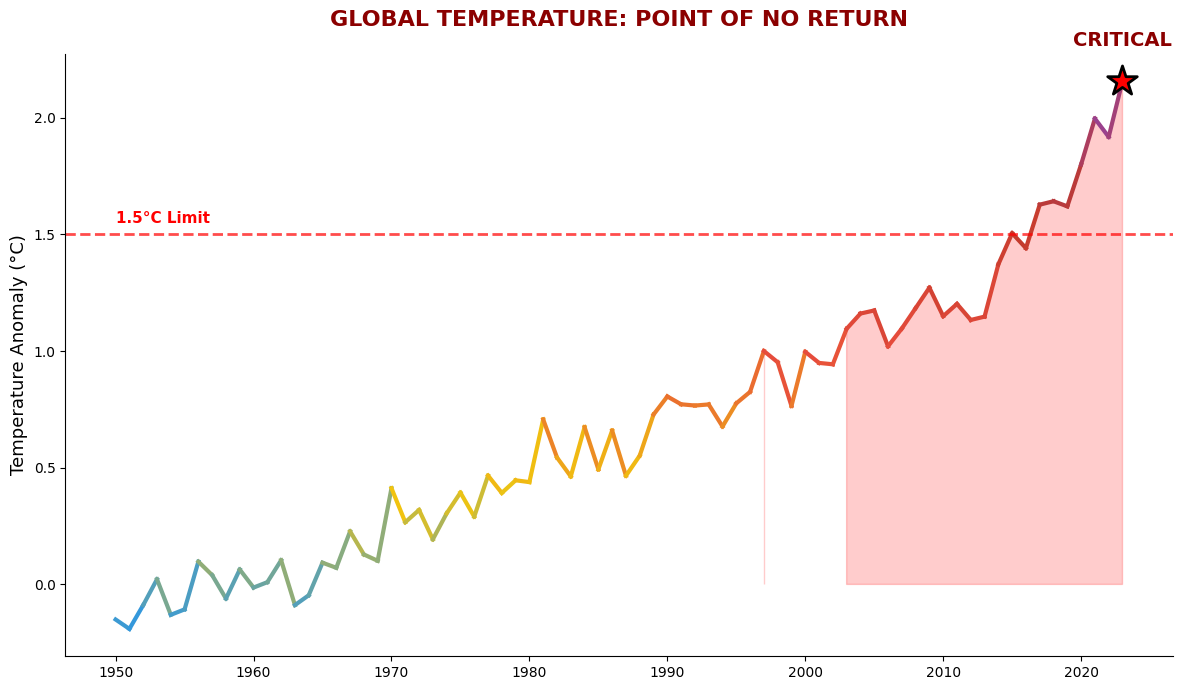

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Create emotionally impactful visualization: Climate emergency
years = np.arange(1950, 2024)
temp_anomaly = np.linspace(-0.2, 1.5, len(years)) + np.random.normal(0, 0.1, len(years))
temp_anomaly[-10:] += np.linspace(0, 0.5, 10)  # Acceleration
fig, ax = plt.subplots(figsize=(12, 7))
# Create custom colormap: Blue to Red (calm to danger)
colors = ['#3498db', '#f1c40f', '#e74c3c', '#c0392b', '#8e44ad']
n_bins = 100
cmap = LinearSegmentedColormap.from_list('danger', colors, N=n_bins)
# Normalize for color mapping
norm = plt.Normalize(min(temp_anomaly), max(temp_anomaly))
# Plot with emotional color gradient
for i in range(len(years)-1):
    ax.plot(years[i:i+2], temp_anomaly[i:i+2],
            color=cmap(norm(temp_anomaly[i])), linewidth=3)
# Add "alarm" elements for blink-test impact
ax.scatter(years[-1], temp_anomaly[-1], s=500, c='red', marker='*',
           edgecolors='black', linewidth=2, zorder=5)
ax.text(years[-1], temp_anomaly[-1]+0.15, 'CRITICAL', fontsize=14,
        fontweight='bold', ha='center', color='darkred')
# Fill area with warning color
ax.fill_between(years, temp_anomaly, 0,
                where=[t > 1.0 for t in temp_anomaly],
                color='red', alpha=0.2, label='Danger Zone')
# Remove scientific clutter for emotional impact
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Temperature Anomaly (°C)', fontsize=13)
ax.set_title('GLOBAL TEMPERATURE: POINT OF NO RETURN', fontsize=16,
             fontweight='bold', color='darkred', pad=20)
# Add horizontal reference at 1.5C
ax.axhline(y=1.5, color='red', linestyle='--', alpha=0.7, linewidth=2)
ax.text(1950, 1.55, '1.5°C Limit', fontsize=11, color='red', fontweight='bold')
plt.tight_layout()
plt.show()